# Test Results Comparison between HRDPS and CaSR Outputs

## Surface currents

In [ ]:
# path and variables

# Date: 2023-03-01

# CaSR results paths

'/ocean/jqiu/results/CaSR/DDmmmYY/SalishSea_1h_YYYYMMDD_YYYYMMDD_grid_U.nc'
'/ocean/jqiu/results/CaSR/DDmmmYY/SalishSea_1h_YYYYMMDD_YYYYMMDD_grid_V.nc'

# CaSR results variables

# 'vozocrtx', 'vomecrty', 'nav_lat', 'nav_lon', 'time_counter'

# HRDPS results paths

# '/results2/SalishSea/nowcast-green.202111/DDmmmYY/SalishSea_1h_YYYYMMDD_YYYYMMDD_grid_U.nc'
# '/results2/SalishSea/nowcast-green.202111/DDmmmYY/SalishSea_1h_YYYYMMDD_YYYYMMDD_grid_V.nc'

# HRDPS results variables

# 'vozocrtx', 'vomecrty', 'nav_lat', 'nav_lon', 'time_counter'


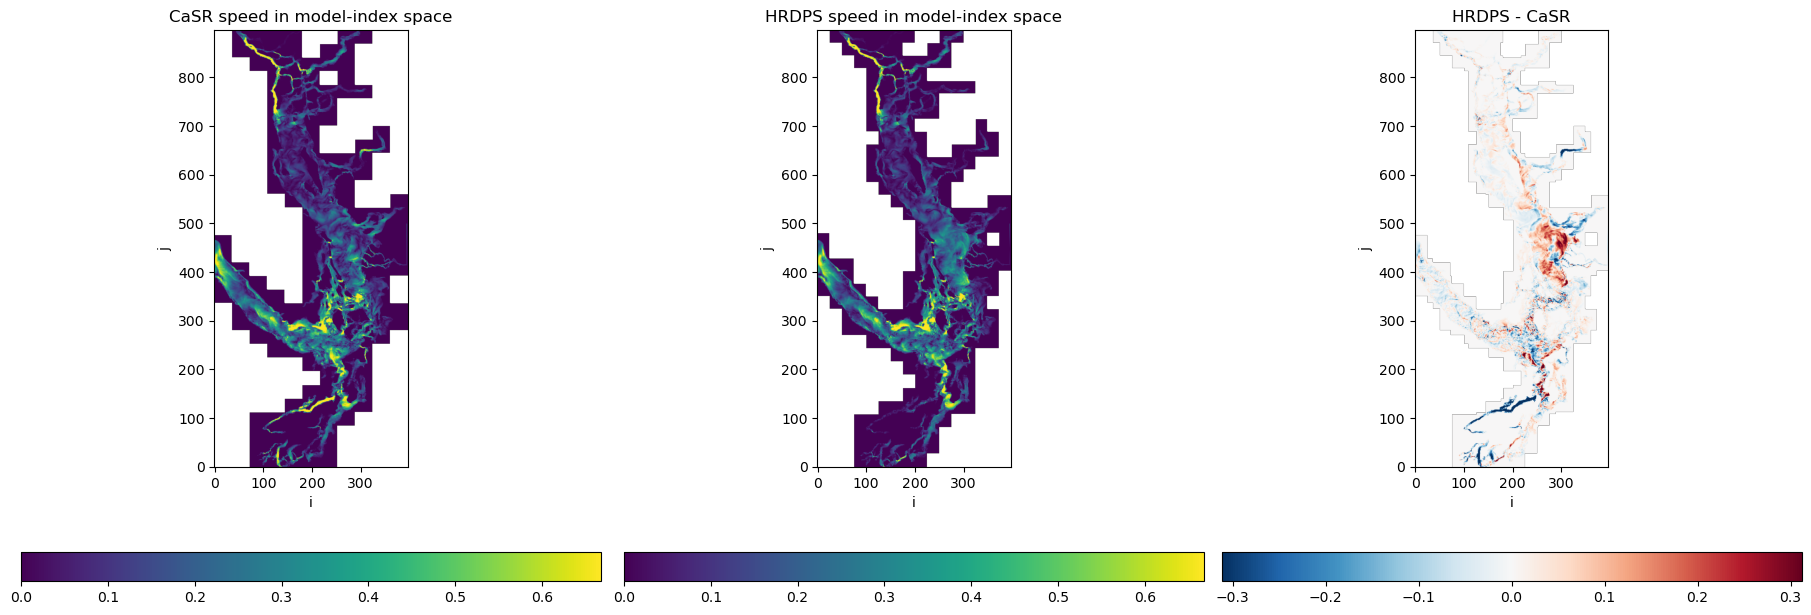

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

im0 = axes[0].imshow(
    casr_plot,
    origin="lower",
    cmap="viridis",
    vmin=0,
    vmax=speed_vmax,
)
axes[0].set_title("CaSR speed in model-index space")
plt.colorbar(im0, ax=axes[0], orientation="horizontal", pad=0.08)

im1 = axes[1].imshow(
    hrdps_plot,
    origin="lower",
    cmap="viridis",
    vmin=0,
    vmax=speed_vmax,
)
axes[1].set_title("HRDPS speed in model-index space")
plt.colorbar(im1, ax=axes[1], orientation="horizontal", pad=0.08)

im2 = axes[2].imshow(
    hrdps_plot - casr_plot,
    origin="lower",
    cmap="RdBu_r",
    vmin=-difference_vmax,
    vmax=difference_vmax,
)
axes[2].set_title("HRDPS - CaSR")
plt.colorbar(im2, ax=axes[2], orientation="horizontal", pad=0.08)

for ax in axes:
    ax.set_xlabel("i")
    ax.set_ylabel("j")

plt.show()

Original T-grid coordinate shape: (898, 398)
Velocity shape: (897, 397)
Trimmed coordinate shape: (897, 397)
Coordinate points exactly (-1, -1): 165277
Coordinate points with lon=-1 or lat=-1: 165277
First 20 indices with lon=-1 or lat=-1: [(np.int64(0), np.int64(0)), (np.int64(0), np.int64(1)), (np.int64(0), np.int64(2)), (np.int64(0), np.int64(3)), (np.int64(0), np.int64(4)), (np.int64(0), np.int64(5)), (np.int64(0), np.int64(6)), (np.int64(0), np.int64(7)), (np.int64(0), np.int64(8)), (np.int64(0), np.int64(9)), (np.int64(0), np.int64(10)), (np.int64(0), np.int64(11)), (np.int64(0), np.int64(12)), (np.int64(0), np.int64(13)), (np.int64(0), np.int64(14)), (np.int64(0), np.int64(15)), (np.int64(0), np.int64(16)), (np.int64(0), np.int64(17)), (np.int64(0), np.int64(18)), (np.int64(0), np.int64(19))]
Suspicious-coordinate index range: j=0:896, i=0:396
Invalid coordinate points: 165277
Crop: j=0:897, i=0:397
Cropped shape: (897, 397)
Bad coordinates inside crop: 165277
Points masked afte

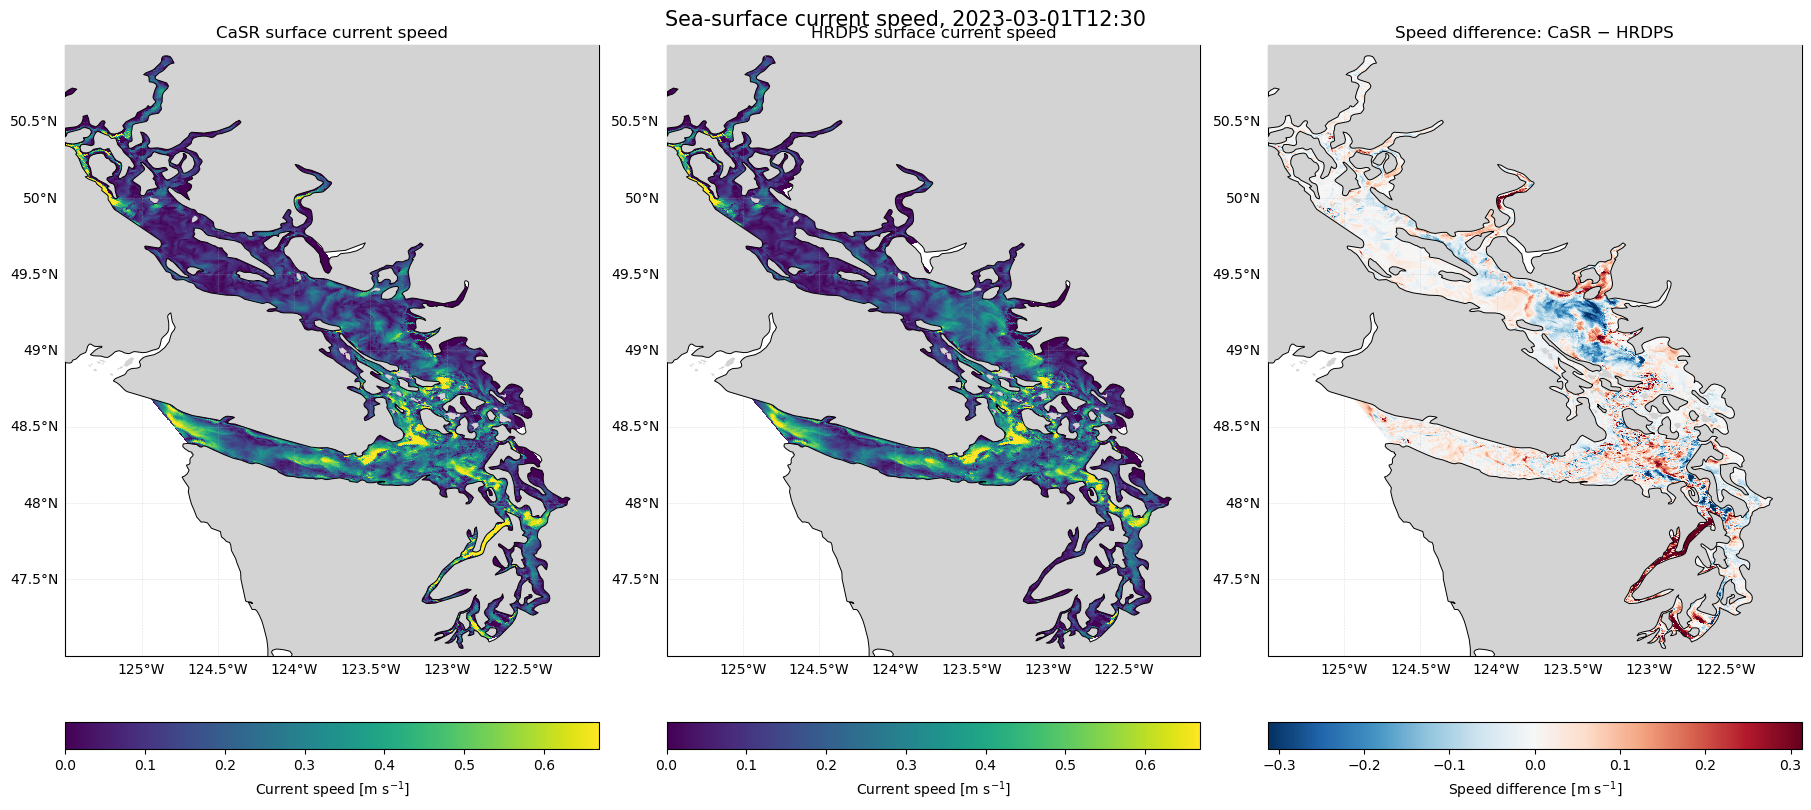

Time: 2023-03-01T12:30
Mean difference (CaSR - HRDPS): 0.00418 m/s
Mean absolute difference: 0.03202 m/s
RMSE: 0.08270 m/s
Maximum absolute difference: 1.65920 m/s


In [7]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import binary_dilation, distance_transform_edt

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------

date_dir = "01mar23"
date_file = "20230301"

casr_u_path = (
    f"/ocean/jqiu/results/CaSR/{date_dir}/"
    f"SalishSea_1h_{date_file}_{date_file}_grid_U.nc"
)

casr_v_path = (
    f"/ocean/jqiu/results/CaSR/{date_dir}/"
    f"SalishSea_1h_{date_file}_{date_file}_grid_V.nc"
)

casr_t_path = (
    f"/ocean/jqiu/results/CaSR/{date_dir}/"
    f"SalishSea_1h_{date_file}_{date_file}_grid_T.nc"
)

hrdps_u_path = (
    f"/results2/SalishSea/nowcast-green.202111/{date_dir}/"
    f"SalishSea_1h_{date_file}_{date_file}_grid_U.nc"
)

hrdps_v_path = (
    f"/results2/SalishSea/nowcast-green.202111/{date_dir}/"
    f"SalishSea_1h_{date_file}_{date_file}_grid_V.nc"
)

time_index = 12


# ---------------------------------------------------------
# Plot region
# ---------------------------------------------------------

lon_min = -125.5
lon_max = -122.0
lat_min = 47.0
lat_max = 51.0


# Broad valid range for Salish Sea model coordinates.
# This deliberately excludes fill coordinates such as (-1, -1)
# while remaining wider than the requested plotting region.
model_lon_min = -130.0
model_lon_max = -120.0
model_lat_min = 45.0
model_lat_max = 53.0


# ---------------------------------------------------------
# Load velocity
# ---------------------------------------------------------

def load_surface_uv(u_path, v_path):
    """
    Load surface U and V velocity components and average the staggered
    fields onto common interior T points.
    """

    with xr.open_dataset(u_path) as ds_u:
        u = (
            ds_u["vozocrtx"]
            .isel(
                time_counter=time_index,
                depthu=0,
            )
            .values
            .astype(float)
        )

        time = ds_u["time_counter"].values[time_index]

    with xr.open_dataset(v_path) as ds_v:
        v = (
            ds_v["vomecrty"]
            .isel(
                time_counter=time_index,
                depthv=0,
            )
            .values
            .astype(float)
        )

    # Average U in the x direction.
    u_t = 0.5 * (
        u[:, :-1]
        + u[:, 1:]
    )

    # Average V in the y direction.
    v_t = 0.5 * (
        v[:-1, :]
        + v[1:, :]
    )

    # Trim to common shape: (y - 1, x - 1).
    u_t = u_t[:-1, :]
    v_t = v_t[:, :-1]

    return u_t, v_t, time


def fill_bad_coordinates_nearest(
    lon_array,
    lat_array,
    bad_mask,
):
    """
    Replace bad plotting coordinates with coordinates from the nearest
    valid grid point.

    Corresponding data points remain masked. These replacement
    coordinates are used only to prevent pcolormesh from constructing
    cells using fill coordinates such as (-1, -1).
    """

    if not np.any(bad_mask):
        return lon_array.copy(), lat_array.copy()

    if np.all(bad_mask):
        raise ValueError(
            "All cropped coordinates are invalid."
        )

    nearest_indices = distance_transform_edt(
        bad_mask,
        return_distances=False,
        return_indices=True,
    )

    lon_filled = lon_array[tuple(nearest_indices)]
    lat_filled = lat_array[tuple(nearest_indices)]

    return lon_filled, lat_filled


casr_u, casr_v, plot_time = load_surface_uv(
    casr_u_path,
    casr_v_path,
)

hrdps_u, hrdps_v, _ = load_surface_uv(
    hrdps_u_path,
    hrdps_v_path,
)


# ---------------------------------------------------------
# Read coordinates directly from grid_T
# ---------------------------------------------------------

with xr.open_dataset(casr_t_path) as ds_t:
    lon_t = ds_t["nav_lon"].values.astype(float)
    lat_t = ds_t["nav_lat"].values.astype(float)


print("Original T-grid coordinate shape:", lon_t.shape)
print("Velocity shape:", casr_u.shape)


# Match the interior velocity arrays.
lon = lon_t[:-1, :-1]
lat = lat_t[:-1, :-1]


print("Trimmed coordinate shape:", lon.shape)


if lon.shape != casr_u.shape:
    raise ValueError(
        "Coordinate and velocity shapes do not match: "
        f"coordinates={lon.shape}, velocity={casr_u.shape}"
    )

if hrdps_u.shape != casr_u.shape:
    raise ValueError(
        "CaSR and HRDPS velocity shapes do not match: "
        f"CaSR={casr_u.shape}, HRDPS={hrdps_u.shape}"
    )


# ---------------------------------------------------------
# Diagnose suspicious coordinates
# ---------------------------------------------------------

minus_one_both = (
    np.isclose(lon, -1.0)
    & np.isclose(lat, -1.0)
)

minus_one_either = (
    np.isclose(lon, -1.0)
    | np.isclose(lat, -1.0)
)

print(
    "Coordinate points exactly (-1, -1):",
    np.count_nonzero(minus_one_both),
)

print(
    "Coordinate points with lon=-1 or lat=-1:",
    np.count_nonzero(minus_one_either),
)

if np.any(minus_one_either):
    bad_j, bad_i = np.where(minus_one_either)

    print(
        "First 20 indices with lon=-1 or lat=-1:",
        list(zip(bad_j[:20], bad_i[:20])),
    )

    print(
        "Suspicious-coordinate index range:",
        f"j={bad_j.min()}:{bad_j.max()}, "
        f"i={bad_i.min()}:{bad_i.max()}",
    )


# ---------------------------------------------------------
# Speeds and differences
# ---------------------------------------------------------

casr_speed = np.hypot(
    casr_u,
    casr_v,
)

hrdps_speed = np.hypot(
    hrdps_u,
    hrdps_v,
)

speed_difference = (
    casr_speed
    - hrdps_speed
)


# ---------------------------------------------------------
# Identify invalid coordinates
# ---------------------------------------------------------

valid_coordinates = (
    np.isfinite(lon)
    & np.isfinite(lat)
    & (lon >= model_lon_min)
    & (lon <= model_lon_max)
    & (lat >= model_lat_min)
    & (lat <= model_lat_max)
)

invalid_coordinates = ~valid_coordinates


print(
    "Invalid coordinate points:",
    np.count_nonzero(invalid_coordinates),
)


# Mask data corresponding directly to invalid coordinates.
casr_speed[invalid_coordinates] = np.nan
hrdps_speed[invalid_coordinates] = np.nan
speed_difference[invalid_coordinates] = np.nan


# ---------------------------------------------------------
# Crop by model indices
# ---------------------------------------------------------

inside_region = (
    valid_coordinates
    & (lon >= lon_min)
    & (lon <= lon_max)
    & (lat >= lat_min)
    & (lat <= lat_max)
)

j_valid, i_valid = np.where(inside_region)

if j_valid.size == 0:
    raise ValueError(
        "No valid model coordinates were found inside the requested region."
    )


j0 = j_valid.min()
j1 = j_valid.max() + 1

i0 = i_valid.min()
i1 = i_valid.max() + 1


lon_crop = lon[j0:j1, i0:i1].copy()
lat_crop = lat[j0:j1, i0:i1].copy()

casr_crop = casr_speed[j0:j1, i0:i1].copy()
hrdps_crop = hrdps_speed[j0:j1, i0:i1].copy()

difference_crop = speed_difference[
    j0:j1,
    i0:i1,
].copy()


print(f"Crop: j={j0}:{j1}, i={i0}:{i1}")
print("Cropped shape:", lon_crop.shape)


# ---------------------------------------------------------
# Build plotting masks
# ---------------------------------------------------------

bad_coordinates_crop = (
    ~np.isfinite(lon_crop)
    | ~np.isfinite(lat_crop)
    | (lon_crop < model_lon_min)
    | (lon_crop > model_lon_max)
    | (lat_crop < model_lat_min)
    | (lat_crop > model_lat_max)
)


outside_region = (
    ~bad_coordinates_crop
    & (
        (lon_crop < lon_min)
        | (lon_crop > lon_max)
        | (lat_crop < lat_min)
        | (lat_crop > lat_max)
    )
)


# A bad coordinate can distort cells that touch it.
# Mask the bad point and one grid-point neighbourhood around it.
bad_coordinate_neighbourhood = binary_dilation(
    bad_coordinates_crop,
    structure=np.ones((3, 3), dtype=bool),
    iterations=1,
)


casr_mask = (
    bad_coordinate_neighbourhood
    | outside_region
    | ~np.isfinite(casr_crop)
)

hrdps_mask = (
    bad_coordinate_neighbourhood
    | outside_region
    | ~np.isfinite(hrdps_crop)
)

difference_mask = (
    bad_coordinate_neighbourhood
    | outside_region
    | ~np.isfinite(difference_crop)
)


casr_crop = np.ma.masked_where(
    casr_mask,
    casr_crop,
)

hrdps_crop = np.ma.masked_where(
    hrdps_mask,
    hrdps_crop,
)

difference_crop = np.ma.masked_where(
    difference_mask,
    difference_crop,
)


print(
    "Bad coordinates inside crop:",
    np.count_nonzero(bad_coordinates_crop),
)

print(
    "Points masked after bad-coordinate dilation:",
    np.count_nonzero(bad_coordinate_neighbourhood),
)


# ---------------------------------------------------------
# Construct safe plotting coordinates
# ---------------------------------------------------------

lon_plot, lat_plot = fill_bad_coordinates_nearest(
    lon_crop,
    lat_crop,
    bad_coordinates_crop,
)


remaining_bad_plot_coordinates = (
    ~np.isfinite(lon_plot)
    | ~np.isfinite(lat_plot)
    | (lon_plot < model_lon_min)
    | (lon_plot > model_lon_max)
    | (lat_plot < model_lat_min)
    | (lat_plot > model_lat_max)
)


print(
    "Bad coordinates remaining in plotting arrays:",
    np.count_nonzero(remaining_bad_plot_coordinates),
)


# ---------------------------------------------------------
# Diagnostic coordinate checks
# ---------------------------------------------------------

valid_plot_coordinates = (
    np.isfinite(lon_plot)
    & np.isfinite(lat_plot)
)

print(
    "Longitude range:",
    np.min(lon_plot[valid_plot_coordinates]),
    np.max(lon_plot[valid_plot_coordinates]),
)

print(
    "Latitude range:",
    np.min(lat_plot[valid_plot_coordinates]),
    np.max(lat_plot[valid_plot_coordinates]),
)


# ---------------------------------------------------------
# Color limits
# ---------------------------------------------------------

casr_values = casr_crop.compressed()
hrdps_values = hrdps_crop.compressed()
difference_values = difference_crop.compressed()


if casr_values.size == 0:
    raise ValueError(
        "No valid CaSR speed values remain after masking."
    )

if hrdps_values.size == 0:
    raise ValueError(
        "No valid HRDPS speed values remain after masking."
    )

if difference_values.size == 0:
    raise ValueError(
        "No valid difference values remain after masking."
    )


all_speed = np.concatenate(
    [
        casr_values,
        hrdps_values,
    ]
)


speed_vmax = np.percentile(
    all_speed,
    99,
)

difference_vmax = np.percentile(
    np.abs(difference_values),
    99,
)


# Avoid an invalid normalization when every difference is zero.
if not np.isfinite(difference_vmax) or difference_vmax == 0:
    difference_vmax = 1.0e-12


difference_norm = TwoSlopeNorm(
    vmin=-difference_vmax,
    vcenter=0,
    vmax=difference_vmax,
)


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

projection = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 8),
    subplot_kw={
        "projection": projection,
    },
    constrained_layout=True,
)


mesh0 = axes[0].pcolormesh(
    lon_plot,
    lat_plot,
    casr_crop,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=speed_vmax,
)

axes[0].set_title(
    "CaSR surface current speed"
)


mesh1 = axes[1].pcolormesh(
    lon_plot,
    lat_plot,
    hrdps_crop,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=speed_vmax,
)

axes[1].set_title(
    "HRDPS surface current speed"
)


mesh2 = axes[2].pcolormesh(
    lon_plot,
    lat_plot,
    difference_crop,
    transform=ccrs.PlateCarree(),
    shading="auto",
    cmap="RdBu_r",
    norm=difference_norm,
)

axes[2].set_title(
    "Speed difference: CaSR − HRDPS"
)


# ---------------------------------------------------------
# Coastline and land
# ---------------------------------------------------------

for ax in axes:
    ax.set_extent(
        [
            lon_min,
            lon_max,
            lat_min,
            lat_max,
        ],
        crs=ccrs.PlateCarree(),
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="none",
        zorder=3,
    )

    ax.coastlines(
        resolution="10m",
        linewidth=0.7,
        zorder=4,
    )

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        linestyle="--",
        alpha=0.4,
    )

    gl.top_labels = False
    gl.right_labels = False


# ---------------------------------------------------------
# Colorbars
# ---------------------------------------------------------

cbar0 = fig.colorbar(
    mesh0,
    ax=axes[0],
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
)

cbar0.set_label(
    "Current speed [m s$^{-1}$]"
)


cbar1 = fig.colorbar(
    mesh1,
    ax=axes[1],
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
)

cbar1.set_label(
    "Current speed [m s$^{-1}$]"
)


cbar2 = fig.colorbar(
    mesh2,
    ax=axes[2],
    orientation="horizontal",
    pad=0.07,
    fraction=0.05,
)

cbar2.set_label(
    "Speed difference [m s$^{-1}$]"
)


plot_time_string = np.datetime_as_string(
    plot_time,
    unit="m",
)

fig.suptitle(
    f"Sea-surface current speed, {plot_time_string}",
    fontsize=15,
)

plt.show()


# ---------------------------------------------------------
# Statistics
# ---------------------------------------------------------

print("Time:", plot_time_string)

print(
    "Mean difference (CaSR - HRDPS):",
    f"{np.ma.mean(difference_crop):.5f} m/s",
)

print(
    "Mean absolute difference:",
    f"{np.ma.mean(np.ma.abs(difference_crop)):.5f} m/s",
)

print(
    "RMSE:",
    f"{np.sqrt(np.ma.mean(difference_crop**2)):.5f} m/s",
)

print(
    "Maximum absolute difference:",
    f"{np.ma.max(np.ma.abs(difference_crop)):.5f} m/s",
)